# T2 — Data Quality Analysis
Sara Milovanova & Biljana Vitanova

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

RESULTS_FILE = "./t2_quality_results.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

df = pd.DataFrame(data)

ISSUE_COLS = [
    "invalid_year", "null_pickup", "null_dropoff", "placeholder_dropoff",
    "same_timestamps", "negative_duration",
    "zero_distance", "negative_distance",
    "zero_passengers", "negative_fare",
    "excessive_duration", "high_fare",
]

df["total_issues"] = df[ISSUE_COLS].sum(axis=1)
df["issue_rate_%"] = (df["total_issues"] / df["total_rows"].replace(0, pd.NA) * 100).round(2)

print(f"Loaded {len(df)} (dataset, year) records.")
df.head(10)

Loaded 83 (dataset, year) records.


,dataset,year,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,total_issues,issue_rate_%
0,fhv_tripdata,2015,63388532,0,0,0,63387762,0,0,0,0,0,0,85,0,63387847,100.00
1,fhv_tripdata,2016,132114083,0,0,0,132112979,0,0,0,0,0,0,28,0,132113007,100.00
2,fhv_tripdata,2017,192309557,0,0,0,72807159,0,5,0,0,0,0,58099,0,72865263,37.89
3,fhv_tripdata,2018,260874754,0,0,0,0,205,7509,0,0,0,0,87697,0,95411,0.04
4,fhv_tripdata,2019,43261276,0,0,0,0,12,66,0,0,0,0,48940,0,49018,0.11
5,fhv_tripdata,2020,14945465,0,0,0,0,0,0,0,0,0,0,11896,0,11896,0.08
6,fhv_tripdata,2021,14805265,0,0,0,0,0,0,0,0,0,0,5248,0,5248,0.04
7,fhv_tripdata,2022,14511664,0,0,0,0,0,0,0,0,0,0,2109,0,2109,0.01
8,fhv_tripdata,2023,15858639,0,0,0,0,0,1,0,0,0,0,4344,0,4345,0.03
9,fhv_tripdata,2024,17630326,0,0,0,0,0,0,0,0,0,0,3946,0,3946,0.02


`issue_rate_%` represents the number of detected quality violations divided by the total number of records. Because a single record may trigger multiple quality checks, this metric should be interpreted as a normalized quality-violation rate rather than the percentage of affected records.

## Quality checks performed

Each original parquet file is processed independently (MAP step). Issues are counted per row and aggregated by `(dataset, year)` via a Dask bag foldby reduce.

| Check | Description |
|---|---|
| `invalid_year` | Pickup year differs from the file's nominal year by more than ±1 |
| `null_pickup` | Pickup datetime is null / unparseable |
| `null_dropoff` | Dropoff datetime is null / unparseable |
| `placeholder_dropoff` | Dropoff timestamp equals the FHV sentinel value 1989-01-01 00:00:00 used as a placeholder for missing dropoff times |
| `same_timestamps` | Pickup == dropoff (zero-duration trip) |
| `negative_duration` | Dropoff earlier than pickup (excluding placeholder dropoff timestamps) |
| `zero_distance` | Trip distance == 0 (yellow, green, fhvhv only) |
| `negative_distance` | Trip distance < 0 (yellow, green, fhvhv only) |
| `zero_passengers` | Passenger count == 0 (yellow, green only) |
| `negative_fare` | Fare amount < 0 (yellow, green, fhvhv only) |
| `excessive_duration` | Trip duration > 24 hours |
| `high_fare` | Fare > $500 (yellow, green, fhvhv only) |

Columns not present in a dataset (e.g. fhv has no fare) always show 0.

In [19]:
LABELS = {
    "invalid_year": "Invalid year",
    "same_timestamps": "Zero duration",
    "negative_duration": "Negative duration",
    "zero_distance": "Zero distance",
    "negative_distance": "Negative distance",
    "zero_passengers": "Zero passengers",
    "negative_fare": "Negative fare",
    "excessive_duration": "Duration >24h",
    "high_fare": "Fare >$500",
    "placeholder_dropoff": "Placeholder dropoff"
}

---
## Yellow Tripdata

In [14]:
ds_name = "yellow_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

# display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
# table = sub[display_cols].copy()
# table["total_rows"] = table["total_rows"].map("{:,}".format)
# table.index.name = "year"
# print(f"{ds_name} — {len(table)} years")
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", 200)
# table

summary_table = (
    sub[["total_rows", "total_issues", "issue_rate_%"]]
    .copy()
)

summary_table.columns = [
    "Rows",
    "Total Issues",
    "Issue Rate (%)"
]

summary_table["Rows"] = summary_table["Rows"].map("{:,}".format)
summary_table["Total Issues"] = summary_table["Total Issues"].map("{:,}".format)

summary_table

,Rows,Total Issues,Issue Rate (%)
year,,,
2001,27,31,114.81
2002,498,739,148.39
2003,50,70,140.00
2004,1,1,100.00
2007,1,1,100.00
2008,771,823,106.74
2009,"170,897,359","798,168",0.47
2010,"169,001,154","1,279,041",0.76
2011,"176,887,272","4,712,581",2.66


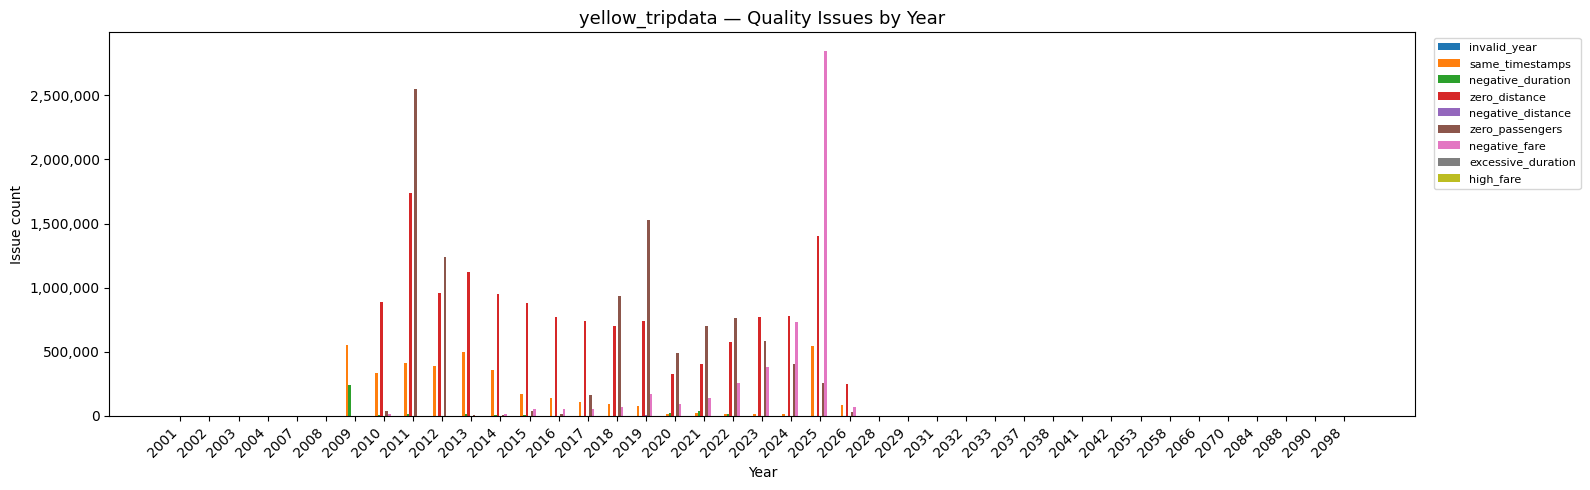

In [17]:
ds_name = "yellow_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

active_issues = [c for c in ISSUE_COLS if sub[c].sum() > 0]
plot_data = sub[active_issues]
years = plot_data.index.tolist()
x = np.arange(len(years))
n = len(active_issues)
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(16, 5))
for i, col in enumerate(active_issues):
    ax.bar(x + i * width - 0.4 + width / 2, plot_data[col], width, label=col)

ax.set_title(f"{ds_name} — Quality Issues by Year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Issue count")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

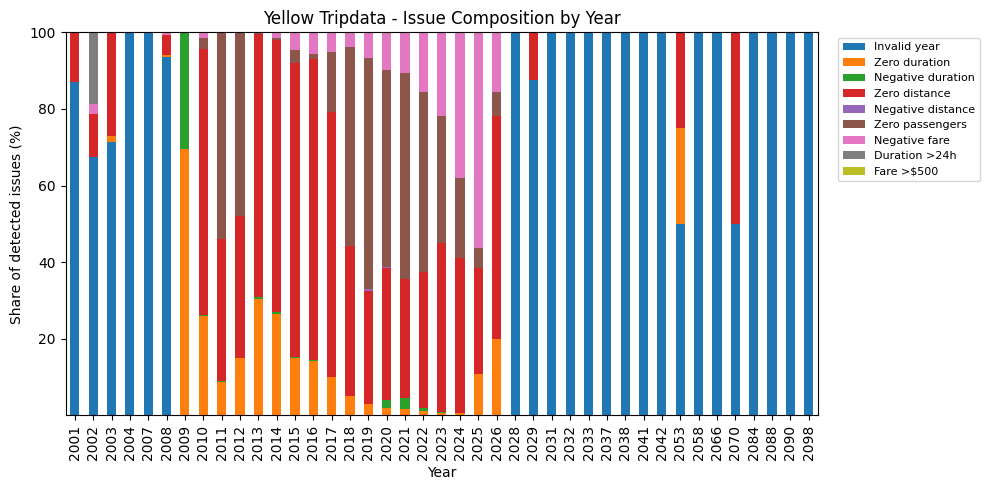

In [20]:
issue_counts = sub[active_issues]

issue_pct = (
    issue_counts
    .div(issue_counts.sum(axis=1), axis=0)
    .fillna(0)
    * 100
)

issue_pct = issue_pct.rename(columns=LABELS)

fig, ax = plt.subplots(figsize=(10,5))

issue_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    f"{ds_name.replace('_', ' ').title()} - Issue Composition by Year"
)

ax.set_ylabel("Share of detected issues (%)")
ax.set_xlabel("Year")

ax.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

---
## Green Tripdata

In [7]:
ds_name = "green_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

green_tripdata — 22 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2008,115,115,0,0,0,1,0,22,0,0,1,0,0,120.87
2009,315,315,0,0,0,1,0,39,0,0,3,0,0,113.65
2010,348,348,0,0,0,1,0,17,0,0,1,0,0,105.46
2012,3,3,0,0,0,0,0,0,0,0,0,0,0,100.00
2014,"15,837,009",0,0,0,0,9978,202,241457,0,3346,11626,2,125,1.68
2015,"19,233,765",0,0,0,0,12831,259,273839,0,6100,30852,11,94,1.68
2016,"16,385,541",0,0,0,0,11225,101,218030,0,4375,32982,2,84,1.63
2017,"11,736,906",0,0,0,0,6640,51,135719,0,1842,26636,1,70,1.46
2018,"8,899,314",0,0,0,0,5477,28,103608,0,12371,23060,1,50,1.62


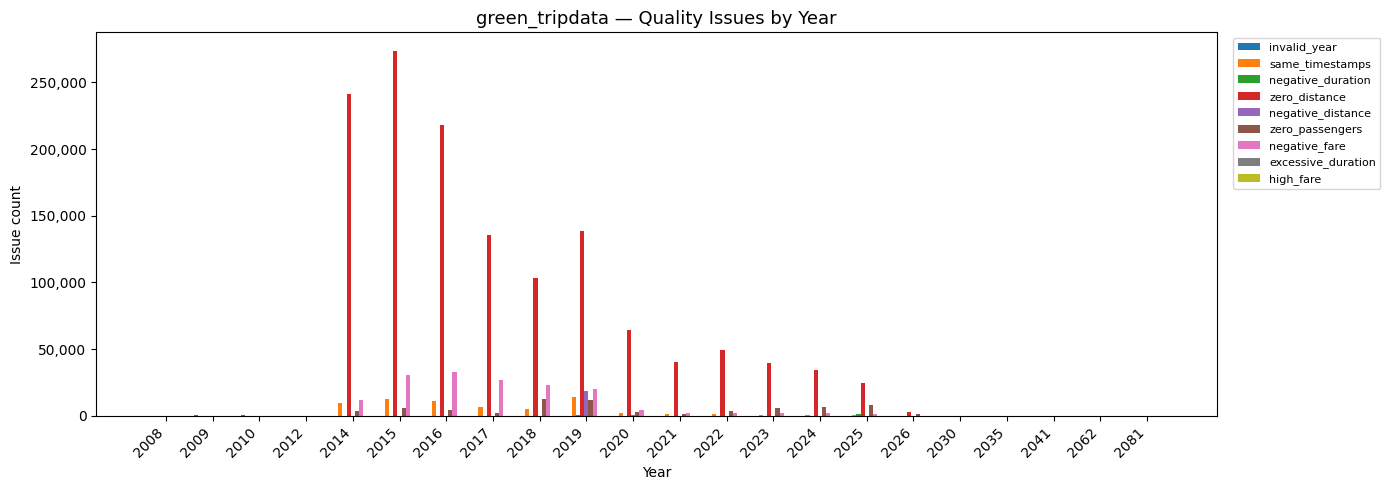

In [8]:
ds_name = "green_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

active_issues = [c for c in ISSUE_COLS if sub[c].sum() > 0]
plot_data = sub[active_issues]
years = plot_data.index.tolist()
x = np.arange(len(years))
n = len(active_issues)
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(active_issues):
    ax.bar(x + i * width - 0.4 + width / 2, plot_data[col], width, label=col)

ax.set_title(f"{ds_name} — Quality Issues by Year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Issue count")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## FHV Tripdata

In [3]:
ds_name = "fhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

fhv_tripdata — 12 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2015,"63,388,532",0,0,0,63387762,0,0,0,0,0,0,85,0,100.00
2016,"132,114,083",0,0,0,132112979,0,0,0,0,0,0,28,0,100.00
2017,"192,309,557",0,0,0,72807159,0,5,0,0,0,0,58099,0,37.89
2018,"260,874,754",0,0,0,0,205,7509,0,0,0,0,87697,0,0.04
2019,"43,261,276",0,0,0,0,12,66,0,0,0,0,48940,0,0.11
2020,"14,945,465",0,0,0,0,0,0,0,0,0,0,11896,0,0.08
2021,"14,805,265",0,0,0,0,0,0,0,0,0,0,5248,0,0.04
2022,"14,511,664",0,0,0,0,0,0,0,0,0,0,2109,0,0.01
2023,"15,858,639",0,0,0,0,0,1,0,0,0,0,4344,0,0.03


### FHV-specific data quality note

The FHV dataset contains a schema inconsistency in older years. Many records use `1989-01-01 00:00:00` as a placeholder value in `dropOff_datetime` rather than a true dropoff timestamp.

Without special handling these records would appear as trips with negative durations because the placeholder date predates the pickup timestamp by decades.

A dedicated `placeholder_dropoff` quality metric was therefore introduced. Placeholder records are counted as a data quality issue but are excluded from duration-based checks (`negative_duration` and `excessive_duration`) to avoid double-counting.

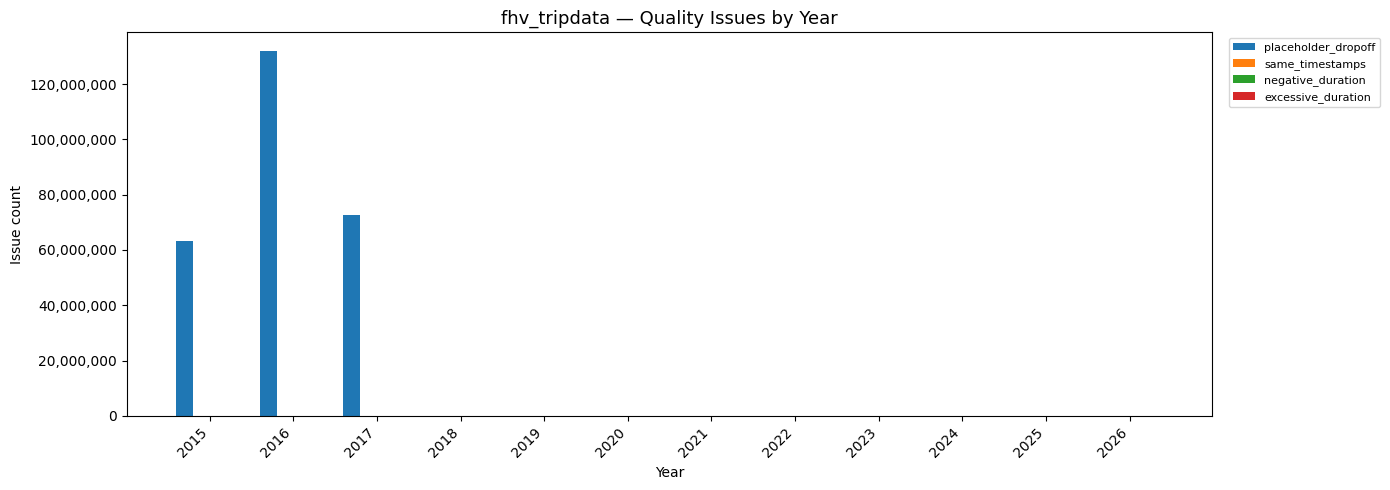

In [4]:
ds_name = "fhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

active_issues = [c for c in ISSUE_COLS if sub[c].sum() > 0]
plot_data = sub[active_issues]
years = plot_data.index.tolist()
x = np.arange(len(years))
n = len(active_issues)
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(active_issues):
    ax.bar(x + i * width - 0.4 + width / 2, plot_data[col], width, label=col)

ax.set_title(f"{ds_name} — Quality Issues by Year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Issue count")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
if active_issues:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## FHVHV Tripdata

In [9]:
ds_name = "fhvhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

fhvhv_tripdata — 8 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2019,"234,630,264",0,0,0,0,1804,7926,514155,0,0,594752,0,2173,0.48
2020,"143,309,871",0,0,0,0,452,7444,152429,0,0,165773,0,1262,0.23
2021,"174,596,652",0,0,0,0,613,7558,53147,0,0,200924,65,2403,0.15
2022,"212,416,083",0,0,0,0,10,8569,43445,0,0,233608,6,4066,0.14
2023,"232,490,020",0,0,0,0,26,8481,40779,0,0,68532,1,4450,0.05
2024,"239,470,448",0,0,0,0,27,9653,34059,0,0,18233,0,5002,0.03
2025,"243,589,684",0,0,0,0,27,12204,28128,0,0,13495,0,6298,0.02
2026,"40,816,059",0,0,0,0,1,0,4802,0,0,34110,0,1017,0.10


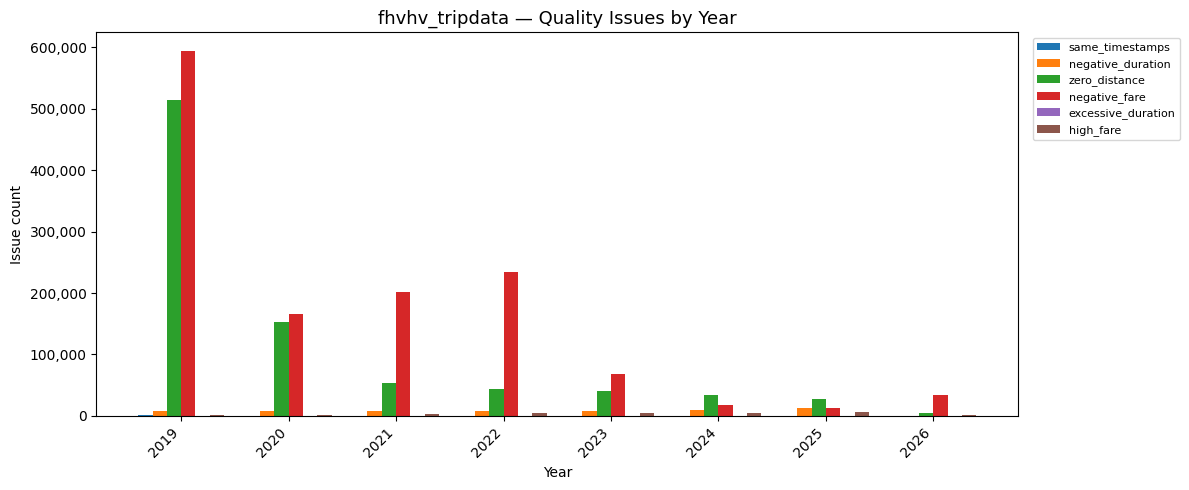

In [10]:
ds_name = "fhvhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

active_issues = [c for c in ISSUE_COLS if sub[c].sum() > 0]
plot_data = sub[active_issues]
years = plot_data.index.tolist()
x = np.arange(len(years))
n = len(active_issues)
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(12, 5))
for i, col in enumerate(active_issues):
    ax.bar(x + i * width - 0.4 + width / 2, plot_data[col], width, label=col)

ax.set_title(f"{ds_name} — Quality Issues by Year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Issue count")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
if active_issues:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## Overall Summary — All Datasets

In [11]:
summary = (
    df.groupby("dataset")[["total_rows", "total_issues"] + ISSUE_COLS]
    .sum()
    .assign(issue_rate_pct=lambda x: (x["total_issues"] / x["total_rows"] * 100).round(2))
)

display_summary = summary.copy()
display_summary["total_rows"]   = display_summary["total_rows"].map("{:,}".format)
display_summary["total_issues"] = display_summary["total_issues"].map("{:,}".format)

print("Aggregate quality summary across all years per dataset:")
display_summary

Aggregate quality summary across all years per dataset:


,total_rows,total_issues,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_pct
dataset,,,,,,,,,,,,,,,
fhv_tripdata,"798,450,799","268,550,042",0,0,0,268307900,261,7874,0,0,0,0,234007,0,33.63
fhvhv_tripdata,"1,521,319,081","2,291,909",0,0,0,0,2960,61835,870944,0,0,1329427,72,26671,0.15
green_tripdata,"84,153,708","1,688,420",789,0,0,0,67895,2387,1366846,19527,70189,160063,85,639,2.01
yellow_tripdata,"1,834,085,397","32,939,207",2718,0,0,0,3831449,372275,14013628,11446,9746697,4953134,3249,4611,1.80


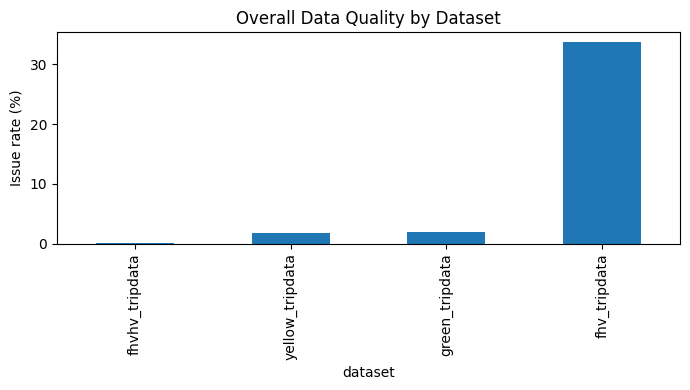

In [21]:
dataset_summary = (
    df.groupby("dataset")
      .agg(
          total_rows=("total_rows","sum"),
          total_issues=("total_issues","sum")
      )
)

dataset_summary["issue_rate"] = (
    dataset_summary["total_issues"]
    / dataset_summary["total_rows"]
    * 100
)

fig, ax = plt.subplots(figsize=(7,4))

dataset_summary["issue_rate"].sort_values().plot.bar(ax=ax)

ax.set_ylabel("Issue rate (%)")
ax.set_title("Overall Data Quality by Dataset")

plt.tight_layout()
plt.show()